In [2]:
!pip -q install rpy2

In [3]:
%load_ext rpy2.ipython

%%R
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

if (!requireNamespace("DESeq2", quietly = TRUE))
    BiocManager::install("DESeq2", ask = FALSE, update = FALSE)

library(DESeq2)

cat("DESeq2 loaded successfully!\n")

SyntaxError: invalid syntax (3039049880.py, line 4)

In [4]:
%load_ext rpy2.ipython

In [5]:
%%R

if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager")
}

if (!requireNamespace("DESeq2", quietly = TRUE)) {
    BiocManager::install("DESeq2", ask = FALSE, update = FALSE)
}

library(DESeq2)

cat("DESeq2 loaded successfully!\n")

DESeq2 loaded successfully!


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/RtmpEmS4Gb/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'BiocVersion', 'DESeq2'
also installing the dependencies ‘XVector’, ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’

trying URL 'https://biocon

In [6]:
from google.colab import files

uploaded = files.upload()

Saving GSE164871_metadata.csv to GSE164871_metadata.csv
Saving GSE164871_raw_counts_GRCh38.p13_NCBI.tsv.gz to GSE164871_raw_counts_GRCh38.p13_NCBI.tsv.gz


In [7]:
import pandas as pd
import numpy as np

counts_file = "/content/GSE164871_raw_counts_GRCh38.p13_NCBI.tsv.gz"
metadata_file = "/content/GSE164871_metadata.csv"

counts = pd.read_csv(
    counts_file,
    sep="\t",
    compression="gzip"
)

metadata = pd.read_csv(metadata_file)

print("Counts shape:", counts.shape)
print("\nMetadata:")
print(metadata)

Counts shape: (39376, 9)

Metadata:
       sample condition
0  GSM5021302   Control
1  GSM5021303   Control
2  GSM5021304   Control
3  GSM5021305   Control
4  GSM5021306   Disease
5  GSM5021307   Disease
6  GSM5021308   Disease
7  GSM5021309   Disease


In [8]:
# Prepare expression matrix

expression = counts.set_index("GeneID")

# Keep the 8 sample columns in metadata order
expression = expression[
    metadata["sample"].tolist()
]

print("Expression shape:", expression.shape)
print(expression.head())

Expression shape: (39376, 8)
           GSM5021302  GSM5021303  GSM5021304  GSM5021305  GSM5021306  \
GeneID                                                                  
100287102           4           7           0           4           3   
653635            829         848         399         343        1032   
102466751          50          62          21          10          61   
107985730           1           1           0           0           2   
100302278           0           0           1           0           1   

           GSM5021307  GSM5021308  GSM5021309  
GeneID                                         
100287102           1           1           4  
653635            405         574         561  
102466751          21          30          24  
107985730           0           0           0  
100302278           0           0           0  


In [9]:
print("Expression samples:")
print(expression.columns.tolist())

print("\nMetadata samples:")
print(metadata["sample"].tolist())

print("\nMATCH:",
      expression.columns.tolist() == metadata["sample"].tolist())

Expression samples:
['GSM5021302', 'GSM5021303', 'GSM5021304', 'GSM5021305', 'GSM5021306', 'GSM5021307', 'GSM5021308', 'GSM5021309']

Metadata samples:
['GSM5021302', 'GSM5021303', 'GSM5021304', 'GSM5021305', 'GSM5021306', 'GSM5021307', 'GSM5021308', 'GSM5021309']

MATCH: True


In [10]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

pandas2ri.activate()

ro.globalenv["count_matrix"] = expression
ro.globalenv["metadata_df"] = metadata

print("Data transferred to R successfully!")

Data transferred to R successfully!


In [11]:
%%R

library(DESeq2)

# Convert counts to matrix
count_matrix <- as.matrix(count_matrix)

# Create sample metadata
coldata <- data.frame(
    condition = factor(
        metadata_df$condition,
        levels = c("Control", "Disease")
    )
)

rownames(coldata) <- metadata_df$sample

# Make sure sample names match
colnames(count_matrix) <- metadata_df$sample

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(
    countData = round(count_matrix),
    colData = coldata,
    design = ~ condition
)

# Remove very low-count genes
dds <- dds[rowSums(counts(dds)) >= 10, ]

# Run DESeq2
dds <- DESeq(dds)

# Disease vs Control
res <- results(
    dds,
    contrast = c("condition", "Disease", "Control")
)

cat("DESeq2 analysis completed successfully!\n")

DESeq2 analysis completed successfully!


converting counts to integer mode
estimating size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing


In [12]:
# Convert DESeq2 results to pandas

res_df = pandas2ri.rpy2py(
    ro.globalenv["res"]
)

res_df = pd.DataFrame(res_df)

res_df["GeneID"] = res_df.index.astype(str)

res_df = res_df.reset_index(drop=True)

print(res_df.head(20))

NotImplementedError: Conversion 'rpy2py' not defined for objects of type '<class 'rpy2.robjects.methods.RS4'>'

In [13]:
%%R

# Convert DESeq2 results to a normal R data frame
res_table <- as.data.frame(res)

# Add GeneID
res_table$GeneID <- rownames(res_table)

# Save as CSV
write.csv(
    res_table,
    "/content/deseq2_results.csv",
    row.names = FALSE
)

cat("DESeq2 results saved successfully!\n")

DESeq2 results saved successfully!


In [14]:
res_df = pd.read_csv("/content/deseq2_results.csv")

print(res_df.head(20))
print("\nShape:", res_df.shape)

        baseMean  log2FoldChange     lfcSE      stat    pvalue      padj  \
0       4.180990       -1.631507  1.194115 -1.366290  0.171848  0.476997   
1     652.849566       -0.813571  0.477211 -1.704846  0.088223  0.335073   
2      30.682377       -0.502707  0.385429 -1.304277  0.192139  0.504454   
3      12.015084       -0.473311  0.597285 -0.792437  0.428106  0.732049   
4     198.461968        0.424296  0.737553  0.575276  0.565105  0.820957   
5       0.703380       -0.381767  2.605976 -0.146497  0.883529       NaN   
6     711.383103       -0.966756  0.585061 -1.652401  0.098453  0.355054   
7      16.895198       -0.619383  0.484347 -1.278800  0.200967  0.515772   
8       3.009108        0.315266  1.023110  0.308145  0.757972       NaN   
9     146.588200        0.161655  0.484264  0.333816  0.738518  0.905933   
10  27828.739058       -2.710004  0.889652 -3.046139       NaN       NaN   
11      1.832433       -0.406485  1.369314 -0.296853  0.766579       NaN   
12    150.00

In [15]:
sig_genes = res_df[
    (res_df["padj"] < 0.05) &
    (abs(res_df["log2FoldChange"]) > 1)
].copy()

upregulated = sig_genes[
    sig_genes["log2FoldChange"] > 1
]

downregulated = sig_genes[
    sig_genes["log2FoldChange"] < -1
]

print("Total significant genes:", len(sig_genes))
print("Upregulated genes:", len(upregulated))
print("Downregulated genes:", len(downregulated))

Total significant genes: 1672
Upregulated genes: 1203
Downregulated genes: 469


KeyError: 'neg_log10_padj'

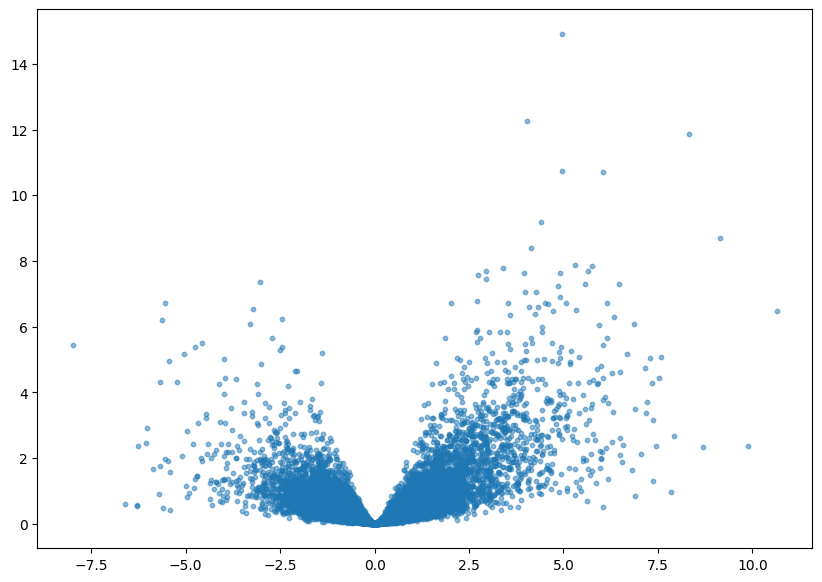

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate -log10 adjusted p-value
res_df["neg_log10_padj"] = -np.log10(
    res_df["padj"].clip(lower=1e-300)
)

plt.figure(figsize=(10, 7))

# All genes
plt.scatter(
    res_df["log2FoldChange"],
    res_df["neg_log10_padj"],
    s=10,
    alpha=0.5
)

# Significant genes
plt.scatter(
    sig_genes["log2FoldChange"],
    sig_genes["neg_log10_padj"],
    s=12,
    alpha=0.7
)

# Threshold lines
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Disease vs Control — Differential Expression")

plt.tight_layout()

# Save for GitHub
plt.savefig(
    "/content/volcano_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Volcano plot created successfully!")

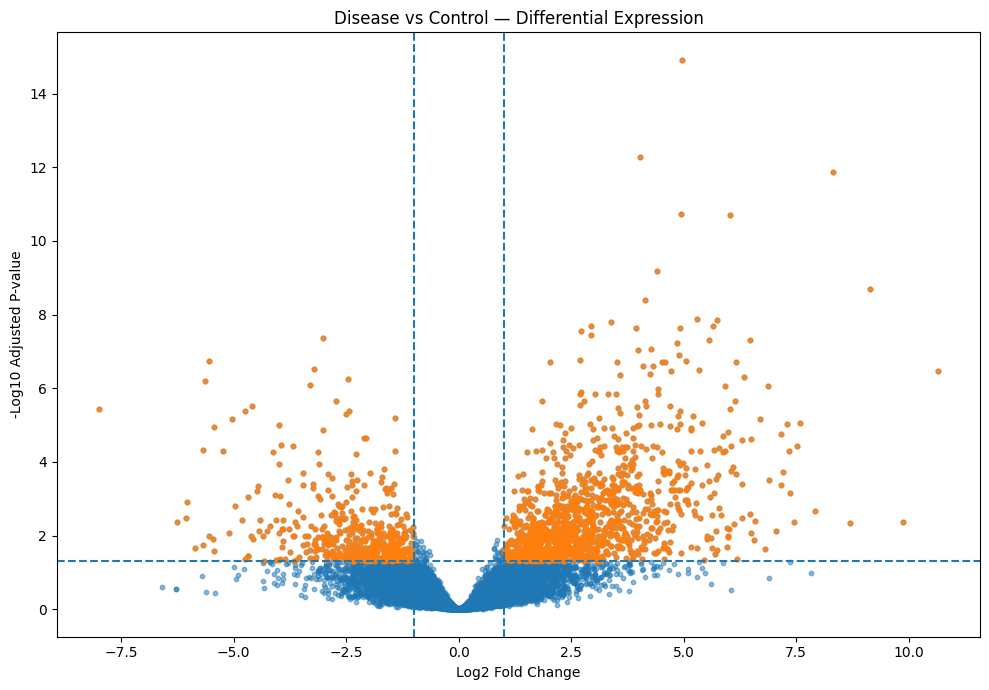

Volcano plot created successfully!


In [17]:
# Fix and recreate volcano plot

import numpy as np
import matplotlib.pyplot as plt

res_df["neg_log10_padj"] = -np.log10(
    res_df["padj"].clip(lower=1e-300)
)

sig_genes["neg_log10_padj"] = -np.log10(
    sig_genes["padj"].clip(lower=1e-300)
)

plt.figure(figsize=(10, 7))

plt.scatter(
    res_df["log2FoldChange"],
    res_df["neg_log10_padj"],
    s=10,
    alpha=0.5
)

plt.scatter(
    sig_genes["log2FoldChange"],
    sig_genes["neg_log10_padj"],
    s=12,
    alpha=0.7
)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Disease vs Control — Differential Expression")

plt.tight_layout()

plt.savefig(
    "/content/volcano_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Volcano plot created successfully!")

In [18]:
# Get normalized counts from DESeq2

normalized_counts = ro.r(
    'counts(dds, normalized=TRUE)'
)

norm_df = pd.DataFrame(
    np.array(normalized_counts),
    index=expression.index,
    columns=expression.columns
)

print("Normalized counts shape:", norm_df.shape)
print(norm_df.head())

ValueError: Shape of passed values is (24696, 8), indices imply (39376, 8)

In [19]:
# Get normalized counts from DESeq2

normalized_counts = ro.r(
    'counts(dds, normalized=TRUE)'
)

# Get the gene IDs that remain after DESeq2 filtering
gene_ids = list(ro.r('rownames(dds)'))

norm_df = pd.DataFrame(
    np.array(normalized_counts),
    index=gene_ids,
    columns=metadata["sample"].tolist()
)

print("Normalized counts shape:", norm_df.shape)
print(norm_df.head())

Normalized counts shape: (24696, 8)
           GSM5021302  GSM5021303  GSM5021304   GSM5021305  GSM5021306  \
100287102    2.223023    4.019578    0.000000    20.571601    1.527683   
653635     460.721577  486.943221  625.259562  1764.014744  525.522806   
102466751   27.787791   35.601981   32.908398    51.429001   31.062879   
100996442   17.784186   14.355637   17.237732     5.142900   17.822963   
729737     349.014656   59.719452  119.097059   149.144104  257.669128   

           GSM5021307  GSM5021308  GSM5021309  
100287102    1.104023    0.811351    3.190658  
653635     447.129221  465.715680  447.489716  
102466751   23.184478   24.340541   19.143945  
100996442    7.728159    5.679460   10.369637  
729737     308.022352   25.963244  319.065751  


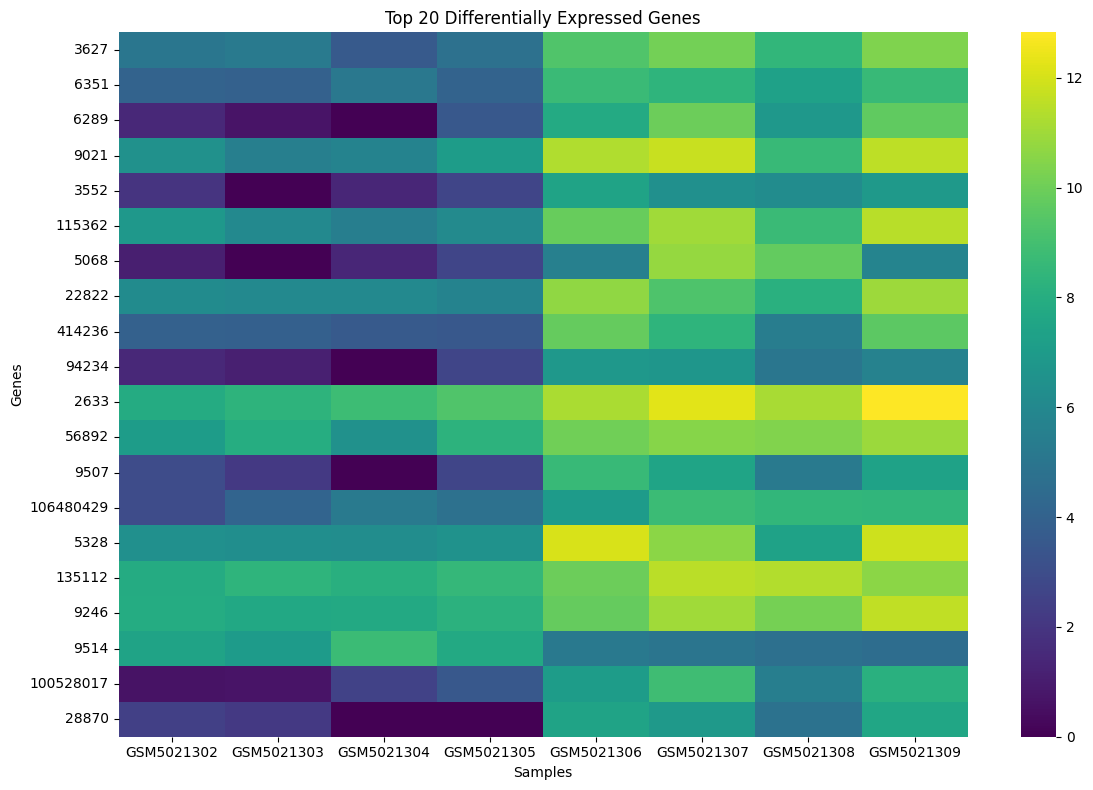

Heatmap created successfully!
Genes plotted: 20


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 20 significant genes
top_genes = (
    sig_genes
    .sort_values("padj")
    .head(20)["GeneID"]
    .astype(str)
    .tolist()
)

# Keep only genes present in normalized data
top_genes = [
    gene for gene in top_genes
    if gene in norm_df.index.astype(str)
]

heatmap_data = norm_df.loc[top_genes]

# Log transform
heatmap_data = np.log2(heatmap_data + 1)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    xticklabels=True,
    yticklabels=True
)

plt.title("Top 20 Differentially Expressed Genes")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()

plt.savefig(
    "/content/top_genes_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Heatmap created successfully!")
print("Genes plotted:", len(top_genes))

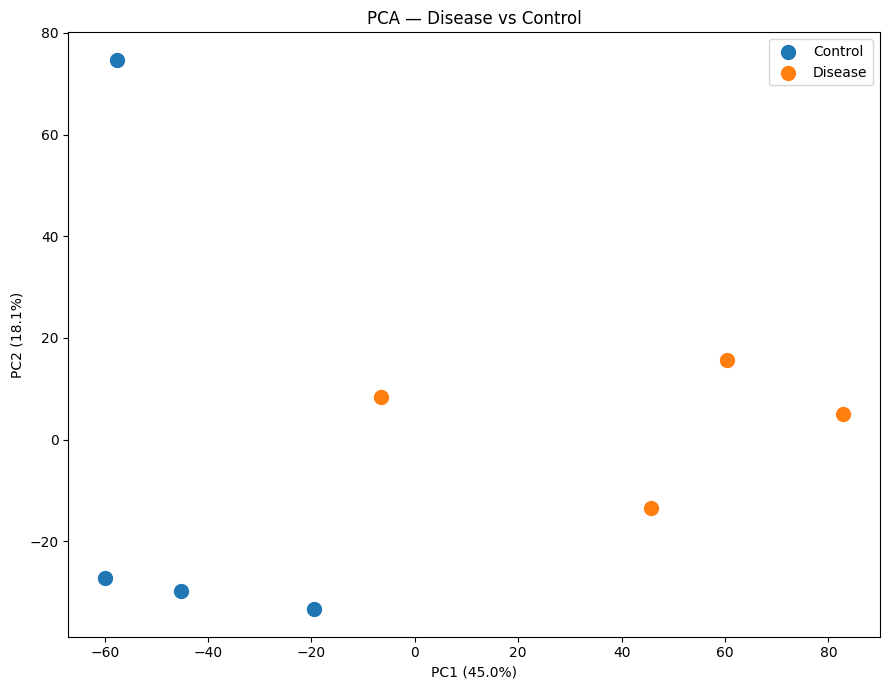

PCA plot created successfully!


In [21]:
# PCA - Disease vs Control

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Log-transform normalized counts
pca_data = np.log2(norm_df + 1)

# Select the 1000 most variable genes
gene_variance = pca_data.var(axis=1)

top_variable_genes = gene_variance.nlargest(1000).index

pca_input = pca_data.loc[top_variable_genes].T

# Run PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(pca_input)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"],
    index=pca_input.index
)

# Add disease/control labels
condition_map = dict(
    zip(metadata["sample"], metadata["condition"])
)

pca_df["Condition"] = pca_df.index.map(condition_map)

# Plot
plt.figure(figsize=(9, 7))

for condition in ["Control", "Disease"]:
    subset = pca_df[pca_df["Condition"] == condition]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=100,
        label=condition
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("PCA — Disease vs Control")

plt.legend()
plt.tight_layout()

# Save for GitHub
plt.savefig(
    "/content/PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PCA plot created successfully!")

In [22]:
# Save DESeq2 results for GitHub

res_df.to_csv(
    "/content/differential_expression.csv",
    index=False
)

sig_genes.to_csv(
    "/content/significant_genes.csv",
    index=False
)

print("Results saved successfully!")
print("differential_expression.csv")
print("significant_genes.csv")

Results saved successfully!
differential_expression.csv
significant_genes.csv


In [23]:
from google.colab import files

files.download("/content/PCA.png")
files.download("/content/volcano_plot.png")
files.download("/content/top_genes_heatmap.png")
files.download("/content/differential_expression.csv")
files.download("/content/significant_genes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>